### Imports

In [75]:
import sys
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

sys.path.insert(0, "../../")
from config import DATASETS_PATH, IMG_SHAPE, SEED

### Tensorflow config

In [76]:
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)
print("cuDNN Enabled:", tf.test.is_built_with_cuda())

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Set the number of intra-op and inter-op threads
NUM_CORES = 12
tf.config.threading.set_intra_op_parallelism_threads(NUM_CORES)
tf.config.threading.set_inter_op_parallelism_threads(NUM_CORES)

# Set for reproducibility
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
cuDNN Enabled: True


### Dataset preparation

In [77]:
# TRAIN_PATH = os.path.join(DATASETS_PATH, 'cropped', 'classifier', 'train_generated')
# TRAIN_PATH = os.path.join(DATASETS_PATH, 'cropped', 'classifier', 'train_generated_only')
# TRAIN_PATH = os.path.join(DATASETS_PATH, 'cropped', 'classifier', 'train_augmented')
# TRAIN_PATH = os.path.join(DATASETS_PATH, 'cropped', 'classifier', 'division', 'train_generated_augmented')
# TEST_PATH = os.path.join(DATASETS_PATH, 'cropped', 'classifier', 'division', 'test')
# VALID_PATH = os.path.join(DATASETS_PATH, 'cropped', 'classifier', 'division', 'validation')

TRAIN_PATH = os.path.join(DATASETS_PATH, 'cropped', 'classifier', 'division', 'train')
TEST_PATH = os.path.join(DATASETS_PATH, 'cropped', 'classifier', 'division', 'test')
VALID_PATH = os.path.join(DATASETS_PATH, 'cropped', 'classifier', 'division', 'validation')

MODEL_PATH = os.path.join('../../', 'models', 'classifier')

# --- PARÁMETROS DEL MODELO ---
IMG_HEIGHT = IMG_SHAPE[0]
IMG_WIDTH = IMG_SHAPE[1]
BATCH_SIZE = 64

In [78]:
# Crear el conjunto de datos de entrenamiento
# Usaremos el 80% de las imágenes en la carpeta 'train' para entrenar.
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical' # Importante para 5 clases
)

# Crear el conjunto de datos de validación
# Usaremos el 20% restante de las imágenes en la carpeta 'train' para validar.
val_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Crear el conjunto de datos de prueba
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Imprimir los nombres de las clases encontradas
class_names = train_ds.class_names
print("\nClases encontradas:", class_names)
print(f"Número de clases: {len(class_names)}")

Found 20131 files belonging to 2 classes.
Using 16105 files for training.
Found 461 files belonging to 2 classes.
Using 92 files for validation.
Found 461 files belonging to 2 classes.

Clases encontradas: ['interphase', 'mitosis']
Número de clases: 2


In [79]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

num_classes = len(class_names)

print("✅ Pipeline de datos optimizado.")

✅ Pipeline de datos optimizado.


### Model definition

#### Own model

In [80]:
# model = keras.Sequential([
#     # Capa de entrada
#     layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    
#     # Bloque Convolucional 1
#     layers.Conv2D(32, (3, 3), padding='same'),
#     layers.BatchNormalization(), # <-- CAPA AGREGADA
#     layers.LeakyReLU(alpha=0.2),   # <-- La activación va después
#     layers.MaxPooling2D(),
    
#     # Bloque Convolucional 2
#     layers.Conv2D(64, (3, 3), padding='same'),
#     layers.BatchNormalization(), # <-- CAPA AGREGADA
#     layers.LeakyReLU(alpha=0.2),   # <-- La activación va después
#     layers.MaxPooling2D(),
    
#     # Bloque Convolucional 4
#     layers.Conv2D(128, (3, 3), padding='same'),
#     layers.BatchNormalization(), # <-- CAPA AGREGADA
#     layers.LeakyReLU(alpha=0.2),   # <-- La activación va después
#     layers.MaxPooling2D(),
    
#     # Bloque Convolucional 3
#     layers.Conv2D(256, (3, 3), padding='same'),
#     layers.BatchNormalization(), # <-- CAPA AGREGADA
#     layers.LeakyReLU(alpha=0.2),   # <-- La activación va después
#     layers.MaxPooling2D(),

#     # Capa para prevenir sobreajuste
#     layers.Dropout(0.2),
    
#     # Capas de Clasificación
#     layers.Flatten(),
    
#     layers.Dense(512),
#     layers.LeakyReLU(alpha=0.2),
#     layers.Dropout(0.5),

#     layers.Dense(256),
#     layers.LeakyReLU(alpha=0.2),

#     layers.Dense(num_classes, activation='softmax') # Capa de salida
# ])

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# # Muestra un resumen de la arquitectura del modelo
# model.summary()

#### VGG19

In [81]:
# # --- 1. Importar VGG19 ---
# from tensorflow.keras.applications import VGG19

# # --- 2. Cargar el modelo base pre-entrenado ---
# base_model_vgg19 = VGG19(
#     input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
#     include_top=False, # Quita la última capa de clasificación de ImageNet
#     weights='imagenet'
# )

# # 1. Descongelar el modelo base
# base_model_vgg19.trainable = True

# # 2. Congelar todas las capas excepto el último bloque convolucional
# # En VGG19, hay 5 bloques. Vamos a re-entrenar solo el último (bloque 5).
# # Congelamos las primeras 15 capas y dejamos las últimas libres.
# for layer in base_model_vgg19.layers[:15]:
#     layer.trainable = False

# # --- 4. Construir tu modelo final ---
# # Añadimos nuestro clasificador encima del modelo base
# model = keras.Sequential([
#     base_model_vgg19,
#     layers.GlobalAveragePooling2D(),

#     layers.Dense(512),
#     layers.LeakyReLU(alpha=0.2),
#     layers.Dropout(0.5),

#     layers.Dense(256),
#     layers.LeakyReLU(alpha=0.2),

#     layers.Dense(num_classes, activation='softmax')
# ])

# # --- 5. Compilar el modelo ---
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# print("\n--- Resumen del Modelo VGG19 ---")
# model.summary()

### ResNET

In [82]:
# # --- 1. Importar ResNet50V2 ---
# from tensorflow.keras.applications import ResNet50V2
# from tensorflow import keras
# from tensorflow.keras import layers

# # --- 2. Cargar el modelo base pre-entrenado ---
# # ¡NOTA! No especificamos 'input_shape' aquí, lo haremos en la capa de reescalado.
# base_model_resnet = ResNet50V2(
#     include_top=False, 
#     weights='imagenet'
# )

# # --- 3. Descongelar el modelo base para Fine-Tuning ---
# base_model_resnet.trainable = True

# # Para ResNet, los bloques tienen nombres como 'conv5_block3_out'
# # Descongelar el último bloque (bloque 5) es un buen punto de partida.
# freeze_until_layer = 'conv5_block1_out' 
# freeze_flag = True

# print(f"Congelando capas hasta encontrar '{freeze_until_layer}'...")
# for layer in base_model_resnet.layers:
#     if layer.name == freeze_until_layer:
#         freeze_flag = False # A partir de aquí, dejamos de congelar
    
#     if freeze_flag:
#         layer.trainable = False

# # (Opcional) Descomenta esto para ver todos los nombres de las capas de ResNet
# # for i, layer in enumerate(base_model_resnet.layers):
# #     print(i, layer.name)

# # --- 4. Construir tu modelo final ---
# model = keras.Sequential([
#     # --- ¡CAPA CRÍTICA! ---
#     # ResNet espera entradas en el rango [-1, 1].
#     # Esta capa convierte [0, 255] -> [0, 2] -> [-1, 1]
#     layers.Rescaling(1./127.5, offset=-1, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    
#     # El modelo base (ahora ResNet)
#     base_model_resnet,
    
#     # Tu cabezal convolucional especializado (¡sigue siendo una gran idea!)
#     layers.Conv2D(512, (3, 3), padding='same'),
#     layers.BatchNormalization(),
#     layers.LeakyReLU(alpha=0.2),
#     layers.Dropout(0.2),

#     # Agregación y clasificador
#     layers.GlobalAveragePooling2D(), 

#     layers.Dense(256),
#     layers.LeakyReLU(alpha=0.2),
#     layers.Dropout(0.2),

#     layers.Dense(128),
#     layers.LeakyReLU(alpha=0.2),

#     layers.Dense(num_classes, activation='softmax')
# ])

# # --- 5. Compilar el modelo ---
# # (Puedes usar tu Focal Loss aquí si la tienes definida)
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
#     loss='categorical_crossentropy', # O tu categorical_focal_loss
#     metrics=['accuracy', tf.keras.metrics.Recall(class_id=PROPHASE_INDEX, name='recall_prophase')] # Sigue monitoreando
# )

# print("\n--- Resumen del Modelo ResNet50V2 ---")
# model.summary()

#### EfficentNet

In [83]:
from tensorflow.keras.applications import EfficientNetB1
base_model_b2_inspect = EfficientNetB1(include_top=False, weights='imagenet')

# Imprime las capas para ver sus nombres e índices
print("Estructura de capas de EfficientNetB1:")
for i, layer in enumerate(base_model_b2_inspect.layers):
    print(i, layer.name)

Estructura de capas de EfficientNetB1:
0 input_layer_12
1 rescaling_16
2 normalization_8
3 rescaling_17
4 stem_conv_pad
5 stem_conv
6 stem_bn
7 stem_activation
8 block1a_dwconv
9 block1a_bn
10 block1a_activation
11 block1a_se_squeeze
12 block1a_se_reshape
13 block1a_se_reduce
14 block1a_se_expand
15 block1a_se_excite
16 block1a_project_conv
17 block1a_project_bn
18 block1b_dwconv
19 block1b_bn
20 block1b_activation
21 block1b_se_squeeze
22 block1b_se_reshape
23 block1b_se_reduce
24 block1b_se_expand
25 block1b_se_excite
26 block1b_project_conv
27 block1b_project_bn
28 block1b_drop
29 block1b_add
30 block2a_expand_conv
31 block2a_expand_bn
32 block2a_expand_activation
33 block2a_dwconv_pad
34 block2a_dwconv
35 block2a_bn
36 block2a_activation
37 block2a_se_squeeze
38 block2a_se_reshape
39 block2a_se_reduce
40 block2a_se_expand
41 block2a_se_excite
42 block2a_project_conv
43 block2a_project_bn
44 block2b_expand_conv
45 block2b_expand_bn
46 block2b_expand_activation
47 block2b_dwconv
48 b

In [84]:
# --- 1. Importar EfficientNetB0 ---
from tensorflow.keras.applications import EfficientNetB1
from tensorflow import keras
from tensorflow.keras import layers

# --- 2. Cargar el modelo base pre-entrenado ---
base_model_effnet = EfficientNetB1(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False, # Quita la última capa de clasificación de ImageNet
    weights='imagenet'
)

# --- 3. Congelar el modelo base ---
base_model_effnet.trainable = True

freeze_until_layer = 'block6a_expand_conv'
freeze_flag = True

print(f"Congelando capas hasta encontrar '{freeze_until_layer}'...")
for layer in base_model_effnet.layers:
    if layer.name == freeze_until_layer:
        freeze_flag = False # A partir de aquí, dejamos de congelar
    
    if freeze_flag:
        layer.trainable = False


# --- 4. Construir tu modelo final ---
# Añadimos nuestro clasificador encima del modelo base
# ¡NOTA: No hay capa de reescalado al principio!
model = keras.Sequential([
    base_model_effnet,

    layers.Dense(512),
    layers.LeakyReLU(alpha=0.2),
    layers.Dropout(0.2),

    layers.GlobalAveragePooling2D(), # Capa para aplanar los features de EfficientNet

    layers.Dense(256),
    layers.LeakyReLU(alpha=0.2),
    layers.Dropout(0.2),

    # layers.Dense(128),
    # layers.LeakyReLU(alpha=0.2),

    layers.Dense(num_classes, activation='softmax')
])



Congelando capas hasta encontrar 'block6a_expand_conv'...


/home/nicolas/Documentos/UTN/INA/giar_ina_dev/.venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [85]:
METRICS = [
    'accuracy', # Sigue siendo útil ver el promedio
    # tf.keras.metrics.Recall(class_id=0, name='recall_anaphase'),
    # tf.keras.metrics.Recall(class_id=1, name='recall_interphase'),
    # tf.keras.metrics.Recall(class_id=2, name='recall_metaphase'),
    # tf.keras.metrics.Recall(class_id=3, name='recall_prophase'),
    # tf.keras.metrics.Recall(class_id=4, name='recall_telophase')
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics= METRICS
)

print("\n--- Resumen del Modelo EfficientNetB0 ---")
model.summary()


--- Resumen del Modelo EfficientNetB0 ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb1 (Functional)     │ (None, 7, 7, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7, 7, 512)      │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,362,953 (28.09 MB)

 Trainable params: 6,095,006 (23.25 MB)

 Non-trainable params: 1,267,947 (4.84 MB)

### Training

In [86]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',      # The metric to monitor
    patience=7,             # Number of epochs to wait for improvement
    verbose=1,               # Print a message when stopping
    restore_best_weights=True, # Restore weights from the best epoch
    mode='min',
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',   # The metric to monitor
    mode='min',
    factor=0.2,           # Factor by which to reduce the learning rate (new_lr = lr * factor)
    patience=5,           # Number of epochs to wait for improvement
    verbose=1,            # Print a message when the LR is updated
    min_delta=0.01,
    min_lr=1e-6           # The minimum learning rate
)

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Assume 'train_ds' is your tf.data.Dataset for training.
# We first need to get all the labels from the dataset.
train_labels = np.concatenate([y for x, y in train_ds], axis=0)
# Convert from one-hot encoding to class indices
train_labels_indices = np.argmax(train_labels, axis=1)

# 1. Calculate the class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_labels_indices),
    y=train_labels_indices
)

# 2. Convert to a dictionary format that Keras expects
class_weights_dict = dict(enumerate(class_weights))
# class_weights_dict[0] = class_weights_dict[0] * 4
# class_weights_dict[1] = class_weights_dict[1] * 0.5
# class_weights_dict[2] = class_weights_dict[2] * 0.5
# class_weights_dict[3] = class_weights_dict[3] * 10 
# class_weights_dict[4] = class_weights_dict[4] * 4
print("Calculated Class Weights:", class_weights_dict)

Calculated Class Weights: {0: np.float64(0.5524492316136114), 1: np.float64(5.26651406147809)}


In [88]:
epochs = 50

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weights_dict,
    callbacks = [lr_scheduler, early_stopping],
)

Epoch 1/50


E0000 00:00:1761506996.560386    9278 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_4_1/efficientnetb1_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


252/252 ━━━━━━━━━━━━━━━━━━━━ 31s 86ms/step - accuracy: 0.7607 - loss: 0.5022 - val_accuracy: 0.7065 - val_loss: 0.6238 - learning_rate: 1.0000e-05
Epoch 2/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.9412 - loss: 0.1575 - val_accuracy: 0.7935 - val_loss: 0.4717 - learning_rate: 1.0000e-05
Epoch 3/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.9649 - loss: 0.0933 - val_accuracy: 0.8261 - val_loss: 0.3890 - learning_rate: 1.0000e-05
Epoch 4/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.9752 - loss: 0.0642 - val_accuracy: 0.8478 - val_loss: 0.3678 - learning_rate: 1.0000e-05
Epoch 5/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.9775 - loss: 0.0559 - val_accuracy: 0.8587 - val_loss: 0.3438 - learning_rate: 1.0000e-05
Epoch 6/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.9810 - loss: 0.0459 - val_accuracy: 0.8696 - val_loss: 0.2884 - learning_rate: 1.0000e-05
Epoch 7/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accurac

2025-10-26 16:33:50.934983: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 30721024 bytes after encountering the first element of size 30721024 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


252/252 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/step - accuracy: 0.9947 - loss: 0.0152 - val_accuracy: 0.9348 - val_loss: 0.1989 - learning_rate: 1.0000e-05
Epoch 12/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/step - accuracy: 0.9946 - loss: 0.0141 - val_accuracy: 0.9348 - val_loss: 0.1932 - learning_rate: 1.0000e-05
Epoch 13/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/step - accuracy: 0.9967 - loss: 0.0101 - val_accuracy: 0.9348 - val_loss: 0.2058 - learning_rate: 1.0000e-05
Epoch 14/50
  1/252 ━━━━━━━━━━━━━━━━━━━━ 43s 171ms/step - accuracy: 1.0000 - loss: 0.0105

2025-10-26 16:35:53.472934: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 59982848 bytes after encountering the first element of size 59982848 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


252/252 ━━━━━━━━━━━━━━━━━━━━ 40s 159ms/step - accuracy: 0.9971 - loss: 0.0095 - val_accuracy: 0.9565 - val_loss: 0.2132 - learning_rate: 1.0000e-05
Epoch 15/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 39s 155ms/step - accuracy: 0.9968 - loss: 0.0084 - val_accuracy: 0.9348 - val_loss: 0.2092 - learning_rate: 1.0000e-05
Epoch 16/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9965 - loss: 0.0091
Epoch 16: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
252/252 ━━━━━━━━━━━━━━━━━━━━ 39s 157ms/step - accuracy: 0.9965 - loss: 0.0091 - val_accuracy: 0.9348 - val_loss: 0.2077 - learning_rate: 1.0000e-05
Epoch 17/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 39s 156ms/step - accuracy: 0.9985 - loss: 0.0053 - val_accuracy: 0.9348 - val_loss: 0.2115 - learning_rate: 2.0000e-06
Epoch 18/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 29s 115ms/step - accuracy: 0.9975 - loss: 0.0058 - val_accuracy: 0.9348 - val_loss: 0.2119 - learning_rate: 2.0000e-06
Epoch 19/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - 

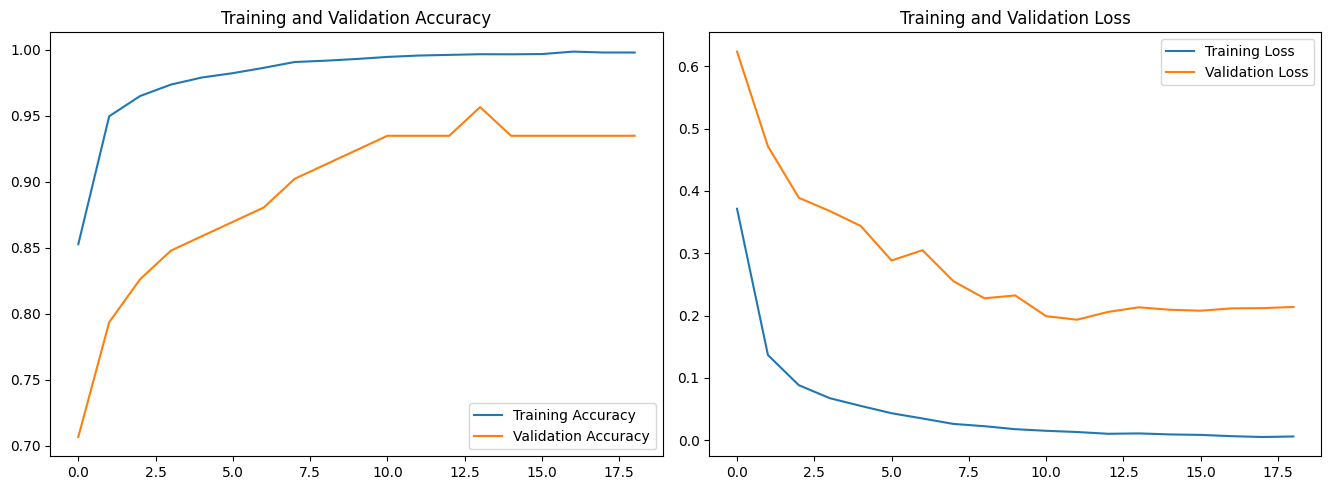

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Visualizar el historial de entrenamiento ---
history_dict = history.history
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

# CORRECCIÓN: Crear el rango de épocas dinámicamente
epochs_range = range(len(acc))

# --- NUEVO: Identificar dinámicamente las métricas de validation recall ---
val_recall_keys = []
for key in history_dict.keys():
    if key.startswith('val_recall'):
        val_recall_keys.append(key)

# --- CAMBIO: Ajustar el tamaño de la figura para 3 plots ---
plt.figure(figsize=(20, 5))

# --- Subplot 1: Accuracy (Cambiado a 1, 3, 1) ---
plt.subplot(1, 3, 1) # <-- CAMBIO
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# --- Subplot 2: Loss (Cambiado a 1, 3, 2) ---
plt.subplot(1, 3, 2) # <-- CAMBIO
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

# --- NUEVO: Subplot 3: Validation Recalls por Clase ---
# plt.subplot(1, 3, 3) # <-- NUEVO PLOT
# if not val_recall_keys:
#     plt.text(0.5, 0.5, 'No "val_recall" metrics found in history', 
#              horizontalalignment='center', verticalalignment='center')
# else:
#     # Iterar y plotear cada métrica de recall encontrada
#     for key in val_recall_keys:
#         val_recall_data = history_dict[key]
#         # Usar el nombre de la métrica como etiqueta
#         plt.plot(epochs_range, val_recall_data, label=key) 

#     plt.legend(loc='lower right')
#     plt.title('Validation Recall per Class')
#     plt.xlabel('Epochs')
#     plt.ylabel('Recall')


# Mostrar la figura completa
plt.tight_layout() # Ajusta los plots para que no se superpongan
plt.show()

### Testing

In [90]:
# --- 2. Evaluar el modelo con el conjunto de prueba ---
print("\nEvaluando el modelo con los datos de prueba...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nPrecisión en el conjunto de prueba: {test_acc:.4f}")


Evaluando el modelo con los datos de prueba...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9350 - loss: 0.2436

Precisión en el conjunto de prueba: 0.9371


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


2025-10-26 16:39:22.937478: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 911ms/step
              precision    recall  f1-score   support

  interphase       0.94      0.97      0.96       321
     mitosis       0.92      0.86      0.89       140

    accuracy                           0.94       461
   macro avg       0.93      0.92      0.92       461
weighted avg       0.94      0.94      0.94       461



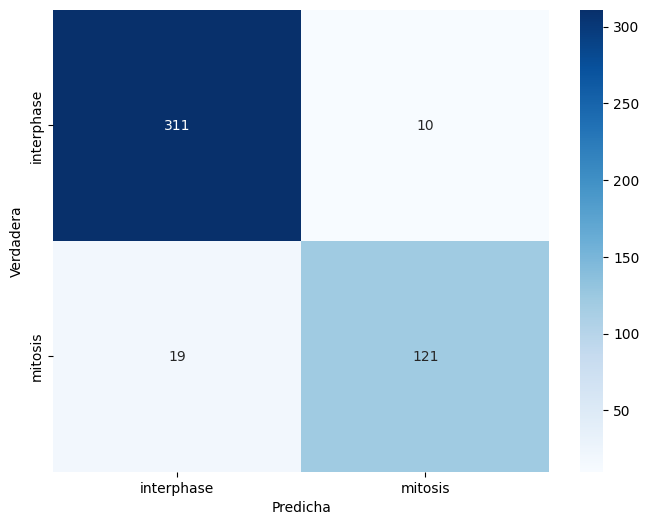

In [91]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Obtener las etiquetas verdaderas y las predicciones del conjunto de test
y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))

# Imprimir el reporte de clasificación
print(classification_report(y_true, y_pred, target_names=class_names))

# Visualizar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicha')
plt.ylabel('Verdadera')
plt.show()

In [92]:
#               precision    recall  f1-score   support

#     anaphase       0.84      0.87      0.85        30
#   interphase       0.96      0.95      0.95       321
#    metaphase       0.91      0.86      0.89        36
#     prophase       0.70      0.76      0.73        41
#    telophase       0.91      0.88      0.89        33

#     accuracy                           0.92       461
#    macro avg       0.86      0.86      0.86       461
# weighted avg       0.92      0.92      0.92       461

Iniciando predicciones en el Test set y guardando imágenes...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
¡Predicciones completadas!

Se encontraron 19 imágenes de 'mitosis' mal clasificadas.


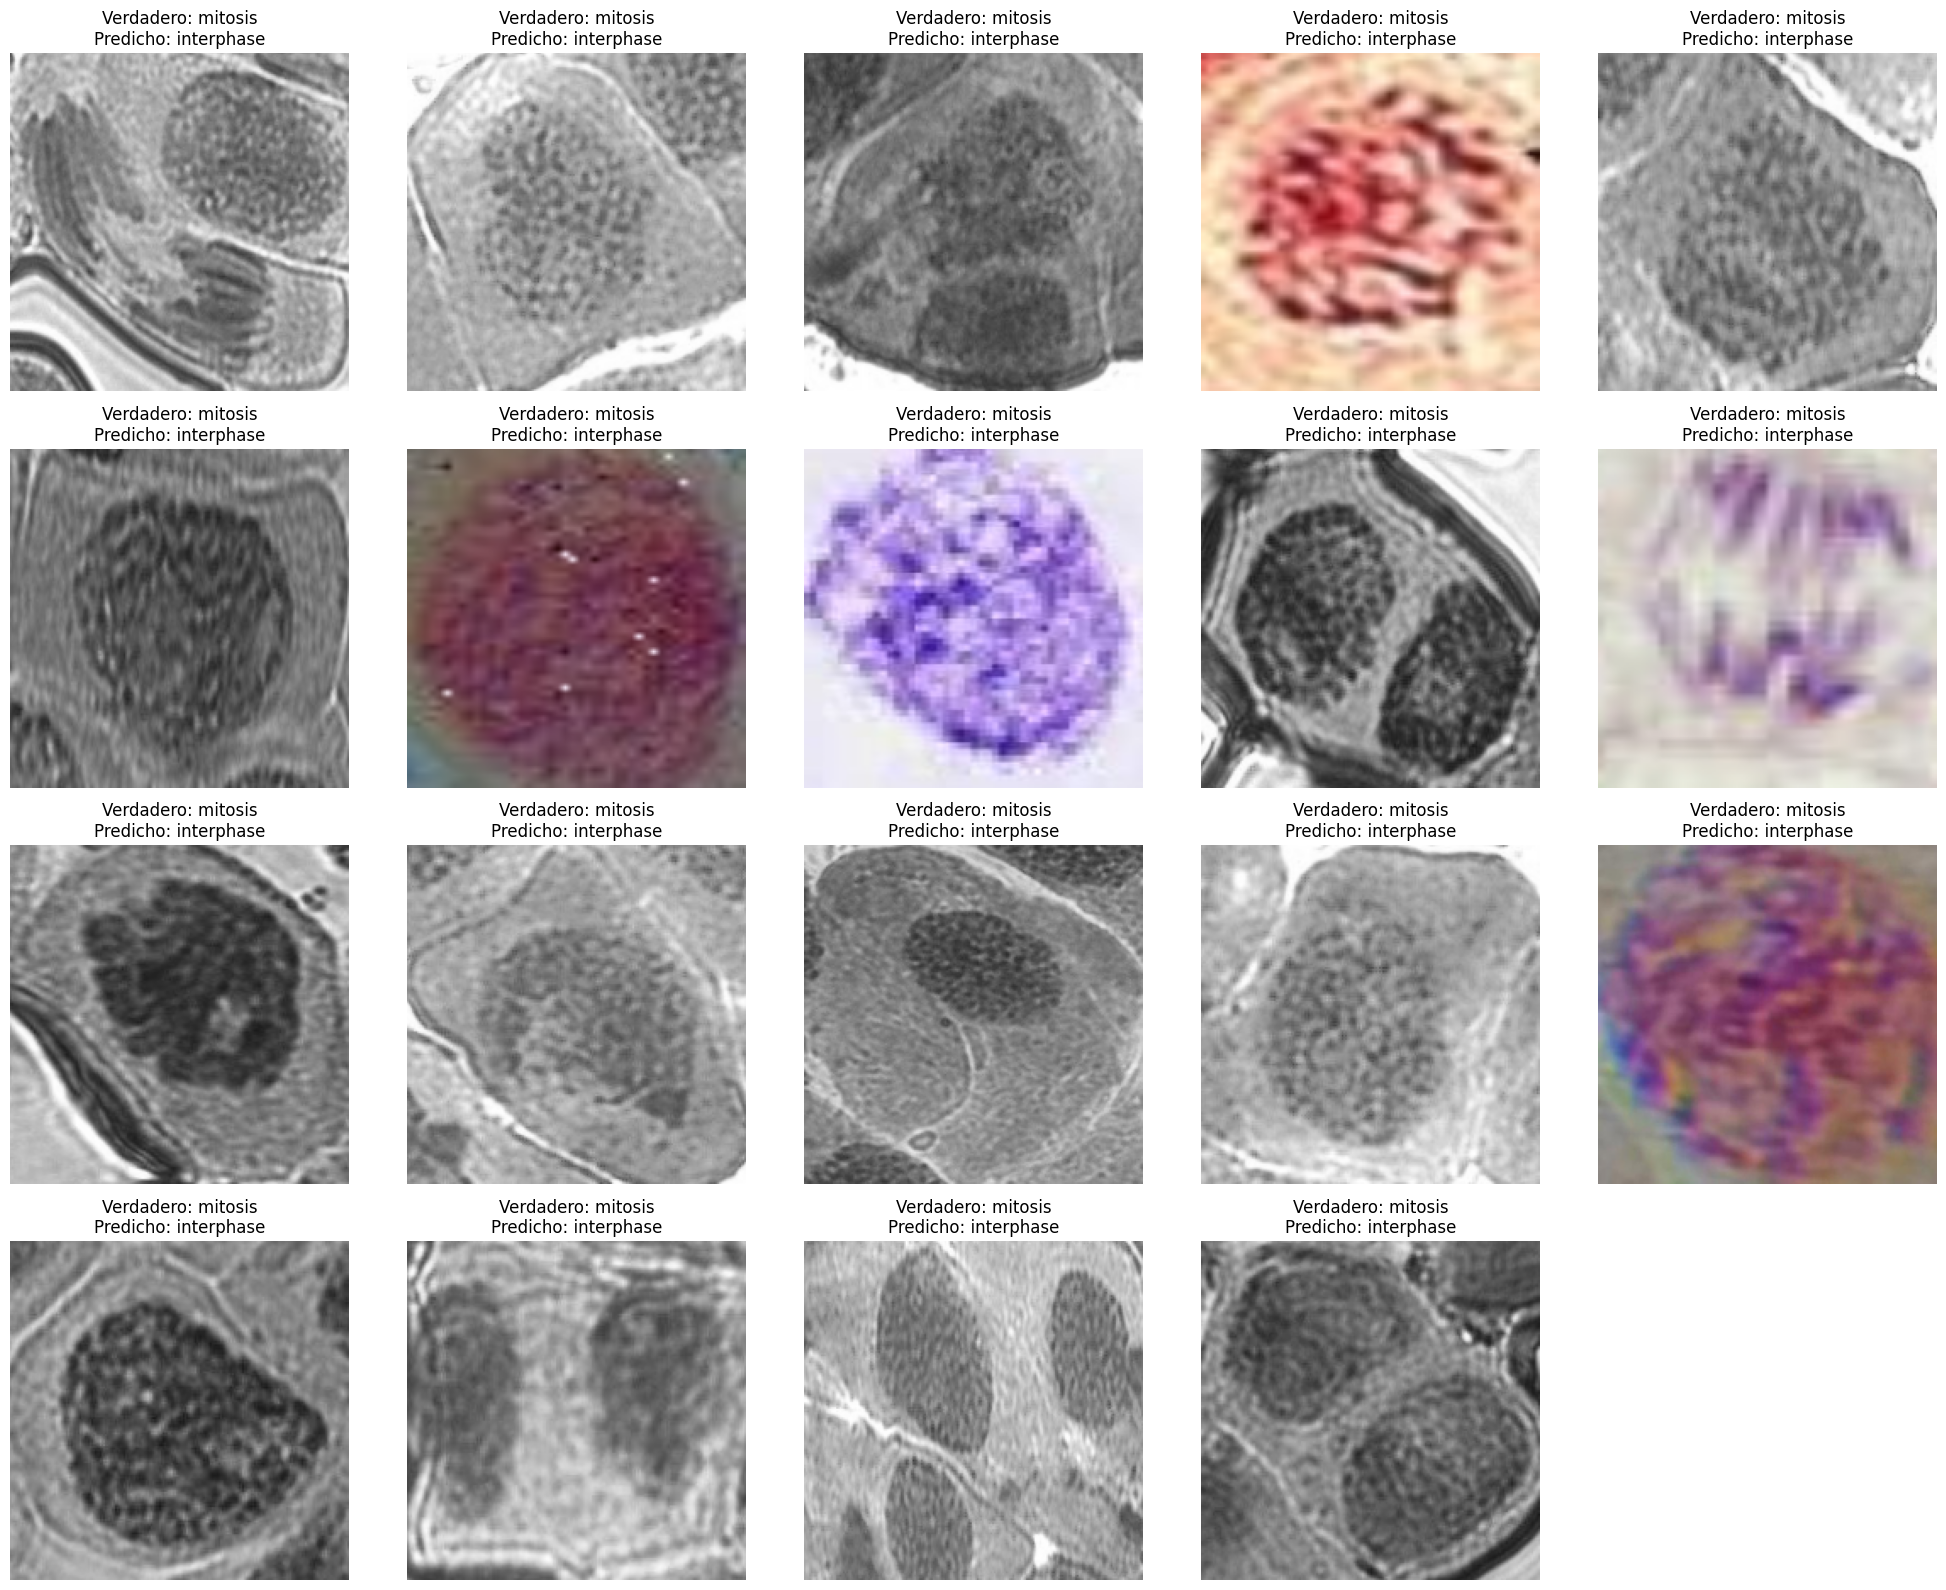

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Recopilar Imágenes, Etiquetas Verdaderas y Predicciones ---
# (Modificamos tu bucle anterior para que también guarde las imágenes)

y_true = []
y_pred = []
all_test_images = [] # <-- NUEVA LISTA PARA GUARDAR IMÁGENES

print("Iniciando predicciones en el Test set y guardando imágenes...")
# Itera sobre el conjunto de datos de prueba
for images, labels in test_ds:
    # Guarda las imágenes (convertidas a numpy)
    all_test_images.extend(images.numpy()) 
    
    # Obtiene las etiquetas verdaderas (convierte de one-hot a índice)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    
    # Realiza predicciones con el modelo
    preds = model.predict(images)
    
    # Obtiene la clase predicha (la de mayor probabilidad)
    y_pred.extend(np.argmax(preds, axis=1))

print("¡Predicciones completadas!")

# --- 2. Definir la clase que queremos analizar ---
try:
    target_class_name = 'mitosis'#'prophase'
    target_class_index = 1#class_names.index(target_class_name)
except ValueError:
    print(f"Error: La clase '{target_class_name}' no se encuentra en la lista class_names.")
    # Detener la ejecución si la clase no existe

# --- 3. Filtrar las imágenes mal clasificadas ---
misclassified_images = []
misclassified_predictions = []

for i in range(len(y_true)):
    # Condición: La etiqueta verdadera es 'prophase' Y la predicción FUE OTRA COSA
    if y_true[i] == target_class_index and y_pred[i] != target_class_index:
        misclassified_images.append(all_test_images[i])
        misclassified_predictions.append(y_pred[i]) # Guardamos el índice de la clase con la que se confundió

print(f"\nSe encontraron {len(misclassified_images)} imágenes de '{target_class_name}' mal clasificadas.")

# --- 4. Plotear las imágenes encontradas ---
if misclassified_images:
    num_images = len(misclassified_images)
    
    # Ajusta el número de filas y columnas para el plot
    # Por ejemplo, 5 imágenes por fila
    cols = 5
    rows = int(np.ceil(num_images / cols))
    
    plt.figure(figsize=(cols * 4, rows * 4))
    
    for i in range(num_images):
        plt.subplot(rows, cols, i + 1)
        
        # Las imágenes del pipeline de TF suelen estar como float32 [0, 255]
        # Matplotlib espera uint8 [0, 255] o float [0, 1]
        # Convertimos a uint8 para asegurarnos de que se muestre bien.
        img_to_plot = misclassified_images[i].astype('uint8')
        plt.imshow(img_to_plot)
        
        # Añadir título con la predicción errónea
        pred_class_name = class_names[misclassified_predictions[i]]
        plt.title(f"Verdadero: {target_class_name}\nPredicho: {pred_class_name}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"¡Felicidades! No se encontraron imágenes de '{target_class_name}' mal clasificadas.")

In [94]:
os.makedirs(MODEL_PATH, exist_ok=True)
model.save(os.path.join(MODEL_PATH, 'vgg19_classifier.keras')) 

### Classify images

In [95]:
# import os
# import shutil
# import numpy as np
# from tensorflow.keras.preprocessing import image
# from tensorflow.keras.models import load_model

# # --- 1. CONFIGURACIÓN ---
# # Modifica estas rutas según tu estructura de carpetas
# UNLABELED_PATH = os.path.join(DATASETS_PATH, 'cropped', 'onion_cell_merged', 'labeled_images', 'classes', 'd')
# OUTPUT_PATH = os.path.join(DATASETS_PATH, 'cropped', 'onion_cell_merged', 'labeled_images', 'mitosis')

# # --- 2. PREPARAR CARPETAS DE SALIDA ---
# # Crear el directorio principal de salida si no existe
# os.makedirs(OUTPUT_PATH, exist_ok=True)

# # Crear una subcarpeta para cada clase
# for class_name in class_names:
#     class_folder = os.path.join(OUTPUT_PATH, class_name)
#     os.makedirs(class_folder, exist_ok=True)

# print(f"Carpetas de salida creadas en: {OUTPUT_PATH}")

In [96]:
# # --- 3. BUCLE DE CLASIFICACIÓN Y COPIA ---
# from tqdm import tqdm
# print("\nIniciando clasificación...")

# model = load_model(os.path.join(MODEL_PATH, 'vgg19_classifier.keras'))

# for filename in tqdm(os.listdir(UNLABELED_PATH)):
#     # Ignorar archivos que no sean imágenes comunes
#     if not filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
#         continue

#     img_path = os.path.join(UNLABELED_PATH, filename)

#     # Cargar y preprocesar la imagen
#     img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
#     img_array = image.img_to_array(img)
#     # El modelo espera un "lote" (batch) de imágenes. 
#     # Añadimos una dimensión extra para crear un lote de 1 imagen.
#     img_array = np.expand_dims(img_array, axis=0)

#     # Realizar la predicción
#     predictions = model.predict(img_array, verbose=0)
    
#     # Obtener el nombre de la clase con la probabilidad más alta
#     predicted_index = np.argmax(predictions[0])
#     predicted_class_name = class_names[predicted_index]
    
#     # Construir la ruta de destino y copiar el archivo
#     destination_folder = os.path.join(OUTPUT_PATH, predicted_class_name)
#     shutil.copy(img_path, destination_folder)
    
#     # print(f"-> Archivo '{filename}' clasificado como '{predicted_class_name}'. Copiado a la carpeta correspondiente.")

# print("\n¡Clasificación completada!")